# Get started with primitives

<Admonition type="note">
  While this documentation uses the primitives from Qiskit Runtime, which allow you to use IBM® backends, the primitives can be run on any provider by using the [backend primitives](#backend) instead.  Additionally, you can use the *reference* primitives to run on a local statevector simulator.  See [Exact simulation with Qiskit primitives](/docs/guides/simulate-with-qiskit-sdk-primitives) for details.
</Admonition>



The steps in this topic describe how to set up primitives, explore the options you can use to configure them, and invoke them in a program.

<Admonition type="note" title="Using Fractional Gates">
  To use the newly supported [fractional gates](./fractional-gates), set `use_fractional_gates=True` when requesting a backend from a `QiskitRuntimeService` instance. For example:

  ```python
  service = QiskitRuntimeService()
  fractional_gate_backend = service.least_busy(use_fractional_gates=True)
  ```

  Note that this is an experimental feature and might change in the future.
</Admonition>



<details>
  <summary><b>Package versions</b></summary>

  The code on this page was developed using the following requirements.
  We recommend using these versions or newer.

  ```
  qiskit[all]~=2.1.1
  qiskit-ibm-runtime~=0.40.1
  ```
</details>



<span id="start-estimator" />

## Get started with Estimator

{/*Verified the v2 examples 2/29/24 - updated 10/29/24*/}

### 1. Initialize the account

Because Qiskit Runtime Estimator is a managed service, you first need to initialize your account. You can then select the QPU you want to use to calculate the expectation value.

Follow the steps in the [Install and set up topic](install-qiskit) if you don't already have an account.



In [1]:
from qiskit_aer import AerSimulator

backend = AerSimulator()

print(backend.name)

aer_simulator


### 2. Create a circuit and an observable

You need at least one circuit and one observable as inputs to the Estimator primitive.



>>> Observable: ['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII',
 'ZZIIIIII']
>>> Parameters: ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])


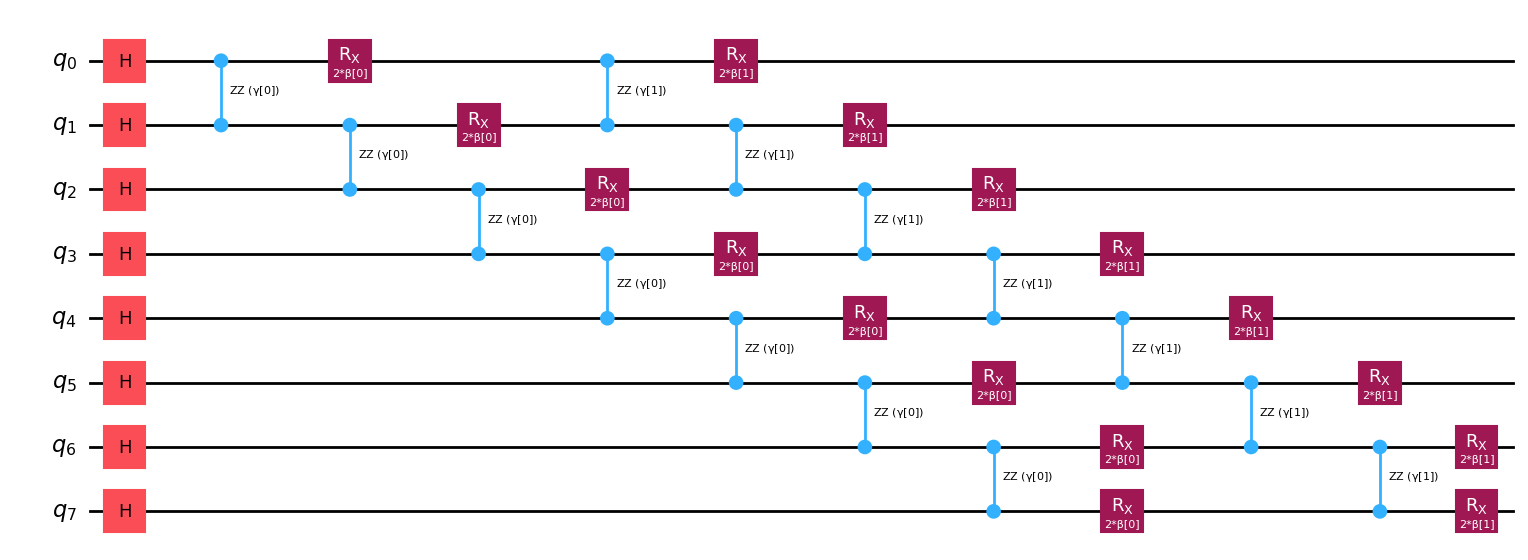

In [2]:
from qiskit.circuit.library import qaoa_ansatz
from qiskit.quantum_info import SparsePauliOp
num_qubits = 8
entanglement = [tuple(edge) for edge in zip(range(num_qubits-1), range(1,num_qubits))]
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement]#+[("ZZ", [2,4], 0.5)]
    ,
    num_qubits=num_qubits,
)
circuit = qaoa_ansatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]

print(f">>> Observable: {observable.paulis}")
print(f">>> Parameters: {circuit.parameters}")
circuit.draw("mpl")

The circuit and observable need to be transformed to only use instructions supported by the QPU (referred to as *instruction set architecture (ISA)* circuits). We'll use the transpiler to do this.



In [3]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict({'rx': 16, 'rzz': 14, 'h': 8})


### 3. Initialize Qiskit Runtime Estimator

When you initialize the Estimator, use the `mode` parameter to specify the mode you want it to run in.  Possible values are `batch`, `session`, or `backend` objects for batch, session, and job execution mode, respectively. For more information, see [Introduction to Qiskit Runtime execution modes.](execution-modes)



In [4]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

### 4. Invoke the Estimator and get results

Next, invoke the `run()` method to calculate expectation values for the input circuits and observables. The circuit, observable, and optional parameter value sets are input as *primitive unified bloc* (PUB) tuples.



In [5]:
job = estimator.run([(isa_circuit, isa_observable, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: e8e938b7-93e3-413e-9d62-f2804abdf858
>>> Job Status: JobStatus.RUNNING


In [6]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.float64(0.049039873889567334)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
  > Expectation value: 1.548095703125
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


<span id="start-sampler" />

## Get started with Sampler

### 1. Initialize the account

Because Qiskit Runtime Sampler is a managed service, you first need to initialize your account. You can then select the QPU you want to use to calculate the expectation value.

Follow the steps in the [Install and set up topic](install-qiskit) if you don't already have an account set up.



In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."

### 2. Create a circuit

You need at least one circuit as the input to the Sampler primitive.



In [8]:
import numpy as np
from qiskit.circuit.library import efficient_su2

circuit = efficient_su2(127, entanglement="linear")
circuit.measure_all()
# The circuit is parametrized, so we will define the parameter values for execution
param_values = np.random.rand(circuit.num_parameters)

Use the transpiler to get an ISA circuit.



In [9]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict([('rz', 3647), ('sx', 2061), ('ecr', 579), ('measure', 127), ('x', 14), ('barrier', 1)])


### 3. Initialize the Qiskit Runtime Sampler

When you initialize the Sampler, use the `mode` parameter to specify the mode you want it to run in.  Possible values are `batch`, `session`, or `backend` objects for batch, session, and job execution mode, respectively. For more information, see [Introduction to Qiskit Runtime execution modes.](execution-modes) Note that Open Plan users cannot submit session jobs.



In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

### 4. Invoke the Sampler and get results

Next, invoke the `run()` method to generate the output. The circuit and optional parameter value sets are input as *primitive unified bloc* (PUB) tuples.



In [11]:
job = sampler.run([(isa_circuit, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: d266i68ut9ds739ge340
>>> Job Status: QUEUED


In [12]:
result = job.result()

# Get results for the first (and only) PUB
pub_result = result[0]
print(
    f"First ten results for the 'meas' output register: {pub_result.data.meas.get_bitstrings()[:10]}"
)

First ten results for the 'meas' output register: ['1100110010110111011000010111100111110111101011010001001110011100010011010111101110000100111110111111101101111111011111001101011', '1000101001000010011101110111000100110111100101110101111011111110001110011101101000000011000001011100011101100111110100111001110', '1100111110111100111111000110010100110010110011111011011101011001010111011110011011101001001001111110011110110110101110101101011', '1100100000001111010011010101111001111110111100001001000001100000100111011011011010101011110000011110100111110111101111011011101', '0110101011001111001101111010010111101111011100101001011101101111011010011110101101011111101000110010110000110001100101010011100', '1111001111001100110011100010001101101101011010101101000000111010011011111011011101111111000011010101011011000111011101110101101', '1001111100000100010100110100101010010100001000110110101111110100110010111111001000101001101010110001110001111111111100111100101', '0101001101110010010100010010101

<span id="backend" />

## Get started with the backend primitives

Unlike provider-specific primitives, backend primitives are generic implementations that can be used with an arbitrary
`backend` object, as long as it implements the [`Backend`](/docs/api/qiskit/qiskit.providers.Backend) interface.

*   The Sampler primitive can be run with any provider by using [`qiskit.primitives.BackendSamplerV2`](/docs/api/qiskit/qiskit.primitives.BackendSamplerV2).
*   The Estimator primitive can be run with any provider by using [`qiskit.primitives.BackendEstimatorV2`](../api/qiskit/qiskit.primitives.BackendEstimatorV2).

Some providers implement primitives natively.  See the [Qiskit Ecosystem page](https://qiskit.github.io/ecosystem#provider) for details.



### Example: BackendEstimator

```python
from qiskit.primitives import BackendEstimatorV2
from <some_qiskit_provider> import QiskitProvider

provider = QiskitProvider()
backend = provider.get_backend('backend_name')
estimator = BackendEstimatorV2(backend)
```

### Example: BackendSampler

```python
from qiskit.primitives import BackendSamplerV2
from <some_qiskit_provider> import QiskitProvider

provider = QiskitProvider()
backend = provider.get_backend('backend_name')
sampler = BackendSamplerV2(backend)
```



### Similarities and differences between backend and Runtime primitives

*   The inputs to and outputs from [`qiskit.primitives.BackendSamplerV2`](/docs/api/qiskit/qiskit.primitives.BackendSamplerV2) and [`qiskit.primitives.BackendEstimatorV2`](../api/qiskit/qiskit.primitives.BackendEstimatorV2)
    follow the same PUB format as the primitives in Qiskit Runtime. See [Primitive inputs and outputs](primitive-input-output) for details.
    However, there can be differences in the fields of the returned metadata.

*   The [`qiskit.primitives.BackendEstimatorV2`](/docs/api/qiskit/qiskit.primitives.BackendEstimatorV2) class offers no measurement or gate error mitigation implementations out-of-the-box, as
    backend primitives are designed to run locally in the user's machine.

*   The [`qiskit.primitives.BackendSamplerV2`](/docs/api/qiskit/qiskit.primitives.BackendSamplerV2) class requires a backend that supports the `memory` option.

*   The backend primitive interfaces expose custom [`SamplerV2`](/docs/api/qiskit/qiskit.primitives.BackendSamplerV2) and [`EstimatorV2`](/docs/api/qiskit/qiskit.primitives.BackendEstimatorV2) `Options` that are different from the Runtime implementations.



## Next steps

<Admonition type="tip" title="Recommendations">
  *   Learn how to [test locally](local-testing-mode) before running on quantum computers.
  *   Review detailed [primitives examples.](primitives-examples)
  *   Practice with primitives by working through the [Cost function lesson](/learning/courses/variational-algorithm-design/cost-functions) in IBM Quantum Learning.
  *   Learn how to transpile locally in the [Transpile](transpile/) section.
  *   Try the [Compare transpiler settings](/docs/tutorials/circuit-transpilation-settings#compare-transpiler-settings) tutorial.
  *   Learn how to [use the primitive options.](runtime-options-overview)
  *   View the API for [Sampler](/docs/api/qiskit-ibm-runtime/options-sampler-options) and [Estimator](/docs/api/qiskit-ibm-runtime/options-estimator-options) options.
  *   Read [Migrate to V2 primitives](/docs/migration-guides/v2-primitives).
</Admonition>



© IBM Corp., 2017-2025